# Human-in-the-Loop

The Human-in-the-Loop (HITL) pattern integrates human judgment into AI workflows. Agents handle routine cases autonomously, while high-risk actions are gated on explicit human approval.

## Implementation with Flyte v2 + the Agent harness

This refactor implements a real gate: the sensitive action — `issue_refund` — is a `@tool(requires_approval=True)`. When the agent decides to call it, the harness **pauses the run on a native Flyte condition** (`flyte.new_condition`) and waits for a human to approve or deny before the tool executes. A condition is a pod-less action that sits in `Paused` until it's signaled — no served form and no extra app to deploy.

#### ADK vs Flyte v2 + Agent harness

| Aspect | ADK | Flyte v2 + `Agent` harness |
|--------|-----|----------------------------|
| **Escalation trigger** | `escalate_to_human` mock tool | `@tool(requires_approval=True)` — real pause-for-approval |
| **Approval transport** | Not shown | Native `flyte.new_condition` — a pod-less condition action that pauses the run |
| **Human decision** | N/A | `flyte signal condition <run> <action> true`/`false` from the CLI |
| **On denial** | N/A | Agent recovers and tries another approach |
| **Personalization** | `CallbackContext` injection | Customer context passed in the message |
| **Routine tools** | `troubleshoot_issue`, `create_ticket` | `@tool` functions — schema from type hints |
| **Secrets** | `os.environ` | `flyte.Secret` injected by cluster |

> **🧭 When to use this pattern — and how Flyte helps**
>
> Use human-in-the-loop where mistakes carry safety, ethical, or financial weight (healthcare, finance, autonomy), where nuance exceeds what the model handles reliably, or to capture high-quality human feedback. In Flyte, `@tool(requires_approval=True)` pauses the run on a native condition (`flyte.new_condition`) until a person signals approve or deny.

### 1. Install dependencies

In [ ]:
!uv pip install "flyte" litellm

### 2. Store your API key

In [ ]:
!flyte create secret ANTHROPIC_API_KEY --value sk-...

### 3. Import dependencies and configure the TaskEnvironment

In [8]:
import json
import uuid
from dataclasses import dataclass, field
from datetime import timedelta

import flyte
import flyte.errors

flyte.init_from_config()

from flyte.ai.agents import Agent, AgentResult, tool
from pydantic import BaseModel, Field
from typing import List

_image = (
    flyte.Image.from_debian_base(name="hitl-agent", python_version=(3, 12))
    .with_pip_packages("litellm")
)

hitl_env = flyte.TaskEnvironment(
    name="hitl_agent",
    image=_image,
    resources=flyte.Resources(cpu="1", memory="1Gi"),
    secrets=[
        flyte.Secret(key="ANTHROPIC_API_KEY", as_env_var="ANTHROPIC_API_KEY"),
    ],
)

### 4. Define the customer context

`CustomerContext` is a typed task input — the agent receives the customer's tier and history and personalizes accordingly.

In [9]:
class CustomerContext(BaseModel):
    """
    Typed customer context passed to the support agent.
    """
    name: str
    tier: str = "standard"           # "standard" | "premium" | "enterprise"
    recent_purchases: List[str] = Field(default_factory=list)
    support_history: List[str] = Field(default_factory=list)

### 5. Define the tools (one gated by human approval)

`troubleshoot_issue` and `create_ticket` are ordinary `@tool`s. `issue_refund` is the sensitive, irreversible action — marked `@tool(requires_approval=True)`, so the harness pauses for a human decision before it runs.

In [10]:
@tool
def troubleshoot_issue(issue: str, device_type: str = "") -> str:
    """Diagnose a technical issue and return step-by-step troubleshooting instructions.

    Args:
        issue: Description of the technical issue.
        device_type: Type of device, e.g. 'laptop' or 'phone'.
    """
    return (
        f"Troubleshooting for '{issue}' ({device_type or 'device'}): "
        "1) restart the device, 2) update firmware, 3) check cables/connections."
    )


@tool
def create_ticket(issue_type: str, details: str) -> str:
    """Create a support ticket and return its ID.

    Args:
        issue_type: Category of the issue.
        details: Full issue description for the ticket.
    """
    return f"TICKET-{uuid.uuid4().hex[:8].upper()} created for {issue_type}."


@tool(requires_approval=True)
def issue_refund(order_id: str, amount_usd: float) -> str:
    """Issue a refund for an order. High-risk and irreversible — requires human approval.

    Args:
        order_id: The order to refund.
        amount_usd: Refund amount in US dollars.
    """
    return f"Refund of ${amount_usd:.2f} issued for order {order_id}."


async def gated_approval(tool: "AgentTool", args: dict) -> bool:
    """Pause the run on a native Flyte condition until a human approves or denies from the CLI.

    `flyte.new_condition` registers a pod-less condition action that sits in `Paused` until it
    is signaled. There is no report banner or approval form on the OSS devbox (the UI approval
    form is Union-only) — you get the paused action and submit the signal from a terminal:

        flyte get run <run-name>                              # find the Paused action (name starts with 'approve-')
        flyte signal condition <run-name> <action-name> true  # or false to deny

    Returning False lets the agent recover and try another approach.
    """
    pretty_args = json.dumps(args, indent=2, default=str)
    condition = await flyte.new_condition.aio(
        f"approve-{tool.name.replace('_', '-')}-{uuid.uuid4().hex[:6]}",
        prompt=(
            f"Approve tool call `{tool.name}`?\n\n"
            f"Arguments:\n```json\n{pretty_args}\n```\n\n"
            "Signal `true` to approve or `false` to deny."
        ),
        prompt_type="markdown",
        data_type=bool,
        timeout=timedelta(minutes=10),
    )
    try:
        return await condition.wait.aio()
    except flyte.errors.ConditionTimedoutError:
        return False


support_bot = Agent(
    name="support",
    # claude-haiku-4-5 under-calls the gated tool: for the Eve scenario it would answer
    # directly instead of invoking issue_refund, so the approval gate never fires. A more
    # capable model reliably makes the deliberate tool call, so the run pauses for approval.
    model="claude-sonnet-4-6",
    instructions=(
        "You are a technical support specialist for an electronics company. Personalize using "
        "the customer context provided. Use troubleshoot_issue to diagnose problems and "
        "create_ticket to log unresolved ones. If the customer is clearly entitled to a refund "
        "(defective product, or troubleshooting failed for a premium/enterprise customer), call "
        "issue_refund — this pauses for human approval before executing. If approval is denied, "
        "apologize and create a ticket for manual follow-up instead."
    ),
    tools=[troubleshoot_issue, create_ticket, issue_refund],
    approval_callback=gated_approval,
    max_turns=10,
)

### 6. Define the support agent task

The task is thin: it packs the customer context into the message and runs the agent. When the agent calls `issue_refund`, the harness blocks the run on human approval — the escalation is enforced by the gate, not by an outer `if result.escalate` branch.

In [11]:
@hitl_env.task(
    retries=1,
    timeout=timedelta(minutes=10),
    cache=flyte.Cache(behavior="disable"),
)
async def support_agent(issue: str, customer: CustomerContext) -> str:
    """Technical support agent with an approval-gated refund action."""
    context = (
        f"Customer: {customer.name} (tier: {customer.tier}). "
        f"Recent purchases: {', '.join(customer.recent_purchases) or 'none'}. "
        f"Past issues: {', '.join(customer.support_history) or 'none'}.\n\n"
        f"Issue: {issue}"
    )
    result: AgentResult = await support_bot.run.aio(context)
    return result.summary or result.error or ""

### 7. Run the approval gate in action

Three scenarios, each exercising a different path:

1. **Alice** (premium, new issue) — the agent troubleshoots; `issue_refund` is never called, so the run completes normally.
2. **Eve** (enterprise, troubleshooting exhausted, defective unit) — the agent calls `issue_refund`, which **pauses the run** on a condition. `run.wait()` blocks until a human signals it: in another terminal, run `flyte get run <run-name>` to find the `Paused` condition action, then `flyte signal condition <run-name> <action-name> true` to approve (or `false` to deny).
3. **Bob** (standard, accidental water damage) — not "clearly entitled" per the agent's instructions, so it declines and creates a ticket — no gated call, no pause.

The gate only fires when the agent actually invokes the gated tool. If no scenario meets the refund criteria, nothing pauses — that's expected, not a broken gate.

In [14]:
SCENARIOS = [
    # 1) ROUTINE — premium customer, brand-new issue. The agent troubleshoots first and
    #    does NOT call issue_refund, so the run completes without pausing.
    (
        "My laptop screen flickers and sometimes goes black.",
        CustomerContext(
            name="Alice", tier="premium",
            recent_purchases=["ThinkPad X1 Carbon"],
            support_history=[],
        ),
    ),
    # 2) APPROVAL GATE FIRES — enterprise customer, troubleshooting already exhausted, a
    #    clear manufacturing defect, and an explicit refund request with order id + amount.
    #    The agent calls issue_refund -> the run PAUSES on a condition. run.wait() below
    #    blocks until you signal it from another terminal (see the previous cell).
    (
        "I've already done every step your support team gave me over the past two weeks — "
        "full restart, firmware update, reseating every cable — and my two-week-old ThinkPad "
        "still won't power on at all. This is a manufacturing defect, not user error. Please "
        "issue a refund of $1899 for order ORD-7788.",
        CustomerContext(
            name="Eve", tier="enterprise",
            recent_purchases=["ThinkPad X1 Carbon"],
            support_history=["Won't power on", "Escalated: dead unit"],
        ),
    ),
    # 3) POLICY BOUNDARY — standard tier, accidental water/physical damage (not a defect).
    #    The agent declines the refund and creates a ticket instead: no gated call, no pause.
    (
        "My phone is unresponsive after I dropped it in water. I want a refund for order ORD-9912.",
        CustomerContext(
            name="Bob", tier="standard",
            recent_purchases=["iPhone 15"],
            support_history=["Battery drain", "Screen crack"],
        ),
    ),
]

for issue, customer in SCENARIOS:
    run = flyte.run(support_agent, issue=issue, customer=customer)
    print(f"Customer: {customer.name} | Issue: {issue[:60]}")
    print(f"  Run: {run.name}")
    print(f"  URL: {run.url}")
    # If the agent calls issue_refund, the run PAUSES on a condition. Approve/deny it from
    # another terminal:
    #   flyte get run <run-name>                              # find the Paused action
    #   flyte signal condition <run-name> <action-name> true  # or false to deny
    run.wait()  # blocks until the condition (if any) is signaled
    print(f"  done: {run.url}\n")

> Building 1 image...

> Building image hitl-agent for environment hitl_agent

✓ Built image for environment hitl_agent: localhost:30000/hitl-agent:3f1e6930f8960ab043f708426dfdea1c

Output()

Customer: Alice | Issue: My laptop screen flickers and sometimes goes black.
  Run: rwb8kkbw676xj8zsw6c8
  URL: http://localhost:30080/v2/domain/development/project/flytesnacks/runs/rwb8kkbw676xj8zsw6c8


...

> Building image hitl-agent for environment hitl_agent

✓ Built image for environment hitl_agent: localhost:30000/hitl-agent:3f1e6930f8960ab043f708426dfdea1c

Output()

Customer: Bob | Issue: My phone is unresponsive after I dropped it in water. I want
  Run: rwkwrgg6vjlqc72whnh4
  URL: http://localhost:30080/v2/domain/development/project/flytesnacks/runs/rwkwrgg6vjlqc72whnh4


  done: http://localhost:30080/v2/domain/development/project/flytesnacks/runs/rwkwrgg6vjlqc72whnh4



When the agent calls `issue_refund`, the run pauses on the condition and `run.wait()` blocks.   

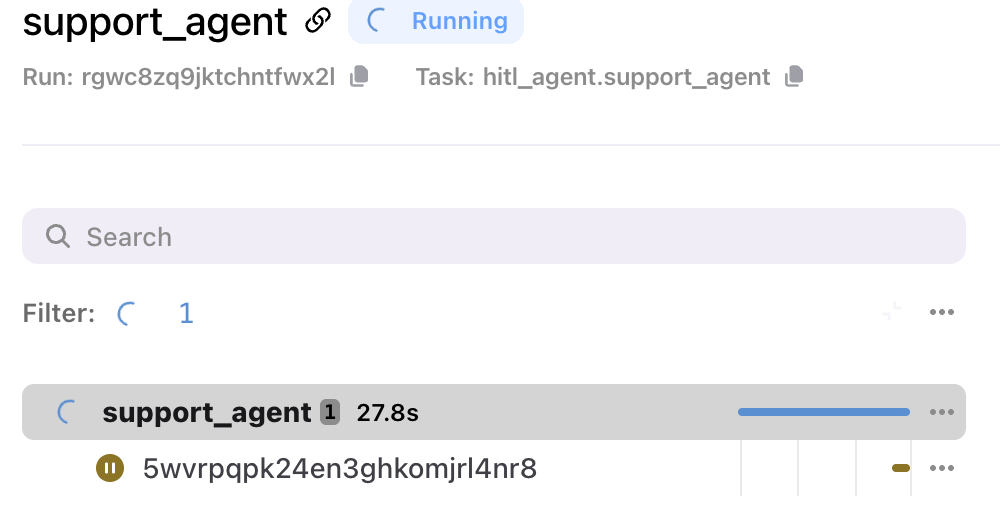

 ### Signaling 

 To unblock the run (either approving or rejecting the tool call) follow the steps:

 1. From the UI, copy the run name:

 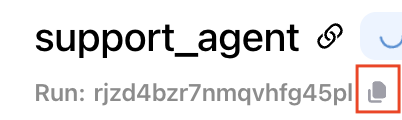
 
 2. On a terminal, get the paused action name:

```bash
flyte get action --in-phase paused <run-name>                           
```
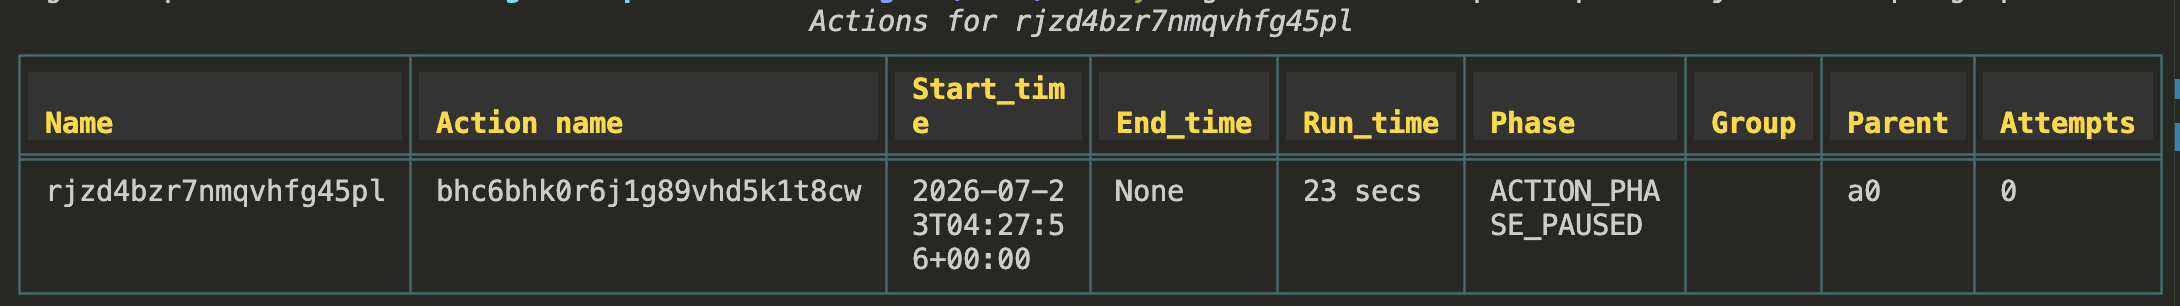

3. Provide the signal the action is waiting for:

```bash
flyte signal condition <run-name> <action-name> true   # approve — or false to deny
```
4. The run completes and the output confirms the tool call was approved:

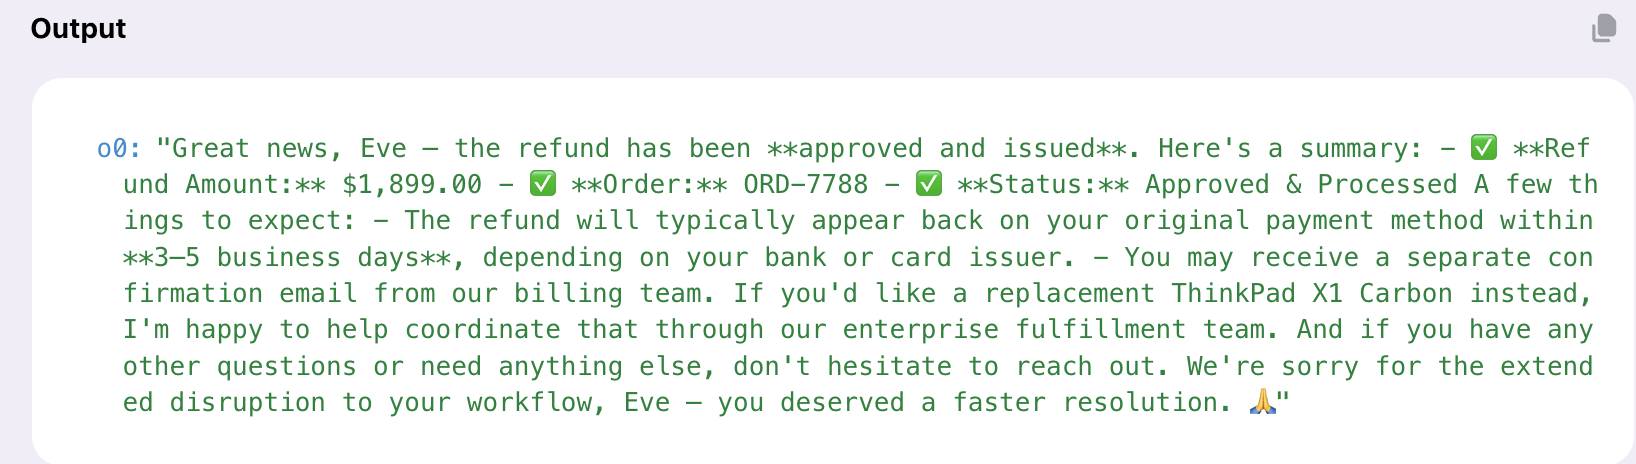


`flyte signal condition` prints the condition's prompt (the tool name and arguments) and coerces your value to the declared type (`true`/`false` for this boolean gate). As soon as you signal, the condition resolves and the agent continues: approve runs `issue_refund`; deny makes the agent apologize and create a ticket instead. 